<a href="https://colab.research.google.com/github/OPCIO0568/2026-1_CV/blob/main/HW%232-3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

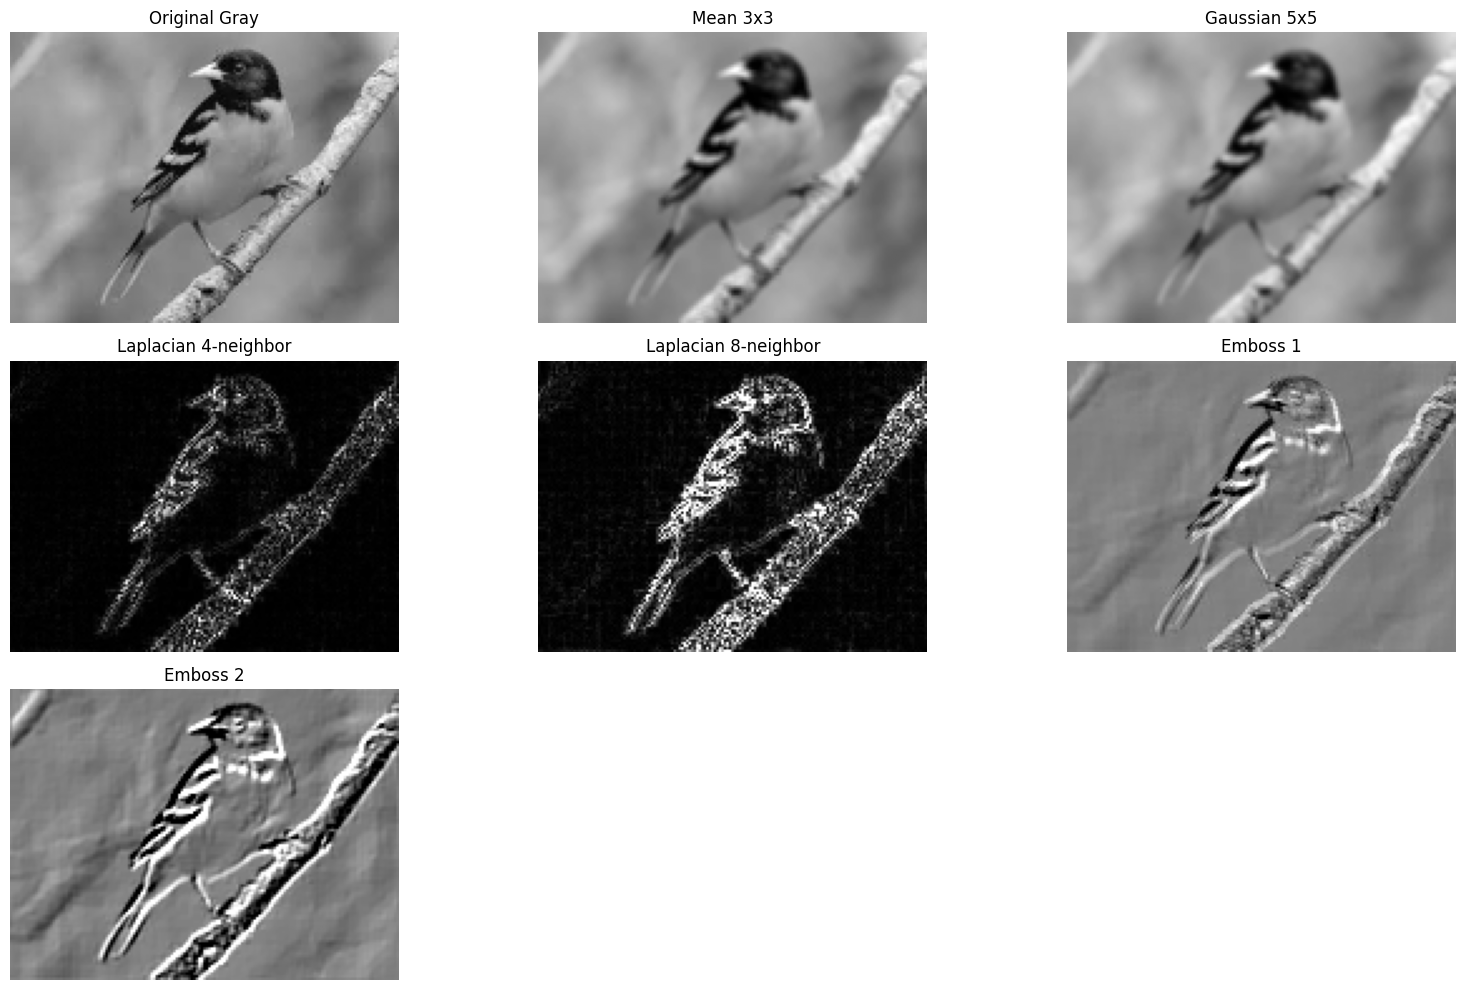

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. 이미지 읽기
img = cv2.imread('/content/bird.jpg')

img = cv2.resize(img, dsize=(0, 0), fx=0.6, fy=0.6)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 2. 마스크 정의
mask_mean_3x3 = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9]
], dtype=np.float32)

mask_gaussian_5x5 = np.array([
    [0.0030, 0.0133, 0.0219, 0.0133, 0.0030],
    [0.0133, 0.0596, 0.0983, 0.0596, 0.0133],
    [0.0219, 0.0983, 0.1621, 0.0983, 0.0219],
    [0.0133, 0.0596, 0.0983, 0.0596, 0.0133],
    [0.0030, 0.0133, 0.0219, 0.0133, 0.0030]
], dtype=np.float32)

mask_laplacian_4 = np.array([
    [0, -1, 0],
    [-1, 4, -1],
    [0, -1, 0]
], dtype=np.float32)

mask_laplacian_8 = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
], dtype=np.float32)

mask_emboss_1 = np.array([
    [-1, 0, 0],
    [ 0, 0, 0],
    [ 0, 0, 1]
], dtype=np.float32)

mask_emboss_2 = np.array([
    [-1, -1, 0],
    [-1,  0, 1],
    [ 0,  1, 1]
], dtype=np.float32)

# 3. 컨볼루션 적용
mean_result = cv2.filter2D(gray, -1, mask_mean_3x3)
gaussian_result = cv2.filter2D(gray, -1, mask_gaussian_5x5)

# Laplacian, emboss
gray16 = np.int16(gray)

lap4 = cv2.filter2D(gray16, -1, mask_laplacian_4)
lap8 = cv2.filter2D(gray16, -1, mask_laplacian_8)
emboss1 = cv2.filter2D(gray16, -1, mask_emboss_1)
emboss2 = cv2.filter2D(gray16, -1, mask_emboss_2)

# 시각화용 변환
lap4_show = np.uint8(np.clip(np.abs(lap4), 0, 255))
lap8_show = np.uint8(np.clip(np.abs(lap8), 0, 255))
emboss1_show = np.uint8(np.clip(emboss1 + 128, 0, 255))
emboss2_show = np.uint8(np.clip(emboss2 + 128, 0, 255))

# 4. 결과 출력
titles = [
    'Original Gray',
    'Mean 3x3',
    'Gaussian 5x5',
    'Laplacian 4-neighbor',
    'Laplacian 8-neighbor',
    'Emboss 1',
    'Emboss 2'
]

images = [
    gray,
    mean_result,
    gaussian_result,
    lap4_show,
    lap8_show,
    emboss1_show,
    emboss2_show
]

plt.figure(figsize=(16, 10))
for i in range(len(images)):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

#흑백 사진으로 만들어 여러 필터를 구현
#평균필터와 가우시안은 주변값의 평균으로 계산하여 경계가 흐려짐
#라플리안은 경계를 검출
#엠보싱은 사진에 입체감 생성